# Features Engineering:

In [13]:

!pip install jinja2

import jinja2

# Standard imports
import os
import sys
from datetime import datetime, timedelta

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

import warnings

warnings.filterwarnings('ignore')

print('Libraries loaded.')


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached MarkupSafe-3.0.2-cp39-cp39-win_amd64.whl.metadata (4.1 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached MarkupSafe-3.0.2-cp39-cp39-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Libraries loaded.


In [2]:
# Paths
DATA_DIR = r"C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data"
CUSTOMERS_PATH = os.path.join(DATA_DIR, 'customers.csv')
TRANSACTIONS_PATH = os.path.join(DATA_DIR, 'transactions.csv')
CAMPAIGNS_PATH = os.path.join(DATA_DIR, 'campaign_tasks.csv')
FE_MODEL_DF_PATH = os.path.join(DATA_DIR, 'fe_model_dataset.csv')

for p in [CUSTOMERS_PATH, TRANSACTIONS_PATH, CAMPAIGNS_PATH]:
    print(p, 'exists:', os.path.exists(p))

# Costanti:
# optimal snapshot-date:
# SNAPSHOT_DATE = '2024-11-11'
REACT_WINDOW = 90
INACTIVITY_DAYS = 120
INACTIVITY_DELTA = timedelta(days=INACTIVITY_DAYS)

C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data\customers.csv exists: True
C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data\transactions.csv exists: True
C:\\Users\\piers\\Desktop\\home\\Sviluppo\\text-llm-learning\\fendi_bc\\Data Scientist Business Case\\data\campaign_tasks.csv exists: True


In [3]:
# Utility functions
def parse_dates(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Convert dates columns into pd.to_datetime columns if columns name in cols."""
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce', utc=True).dt.tz_localize(None)
    return df

In [4]:
df_fe_model = pd.read_csv(FE_MODEL_DF_PATH)


df_fe_model = parse_dates(df_fe_model, ['last_purchase', 'snapshot_date', 'inactive_date_start', 'date_end_react'])

df_fe_model.head()

,customer_id,last_purchase,snapshot_date,inactive_date_start,date_end_react,inactive_days,last_purchase_days,is_active,reactivated,marketing_consent,prev_snap_email,prev_snap_letter,prev_snap_sms,prev_snap_call,tot_campaign,inactive_email,inactive_letter,inactive_sms,inactive_call,inactive_tot_campaign,n_day_acq,quantity_sum,quantity_mean,net_sale_euro_sum,u_price_mean,net_sale_euro_bags,net_sale_euro_rtw,net_sale_euro_shoes,net_sale_euro_slg,net_sale_euro_textile,quantity_bags,quantity_rtw,quantity_shoes,quantity_slg,quantity_textile,gender,age,Africa,Asia,Europe,North America,South America,Oceania,Antarctica,continent
0,CUST_00211,2024-06-01,2024-10-01,2024-09-29,2024-10-30,31,151,1,True,1,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,2,5,2.5,1160.99,330.5350,0.00,494.43,0.00,666.56,0.00,0,1,0,4,0,F,37,1.0,0.0,0.0,0,0,0,0,Asia
1,CUST_00624,2024-06-02,2024-10-01,2024-09-30,2024-12-30,91,211,0,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2.0,1458.08,729.0400,0.00,0.00,0.00,0.00,1458.08,0,0,0,0,2,M,47,1.0,0.0,0.0,0,0,0,0,Asia
2,CUST_00689,2024-06-01,2024-10-01,2024-09-29,2024-12-17,79,199,1,True,1,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,2,5,2.5,2422.41,561.9525,0.00,0.00,523.80,1898.61,0.00,0,0,3,2,0,M,29,1.0,0.0,0.0,0,0,0,0,Asia
3,CUST_00775,2024-06-02,2024-10-01,2024-09-30,2024-10-16,16,136,1,True,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,3,1.5,1803.91,796.4900,421.86,1382.05,0.00,0.00,0.00,2,1,0,0,0,F,51,0.0,1.0,0.0,0,0,0,0,Europe
4,CUST_00857,2024-06-02,2024-10-01,2024-09-30,2024-12-30,91,211,0,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2.0,489.29,244.6450,0.00,0.00,489.29,0.00,0.00,0,0,2,0,0,F,21,1.0,0.0,0.0,0,0,0,0,Asia


# Compongo matrice X e vettore y:

In [5]:
X = df_fe_model[[
    # 'inactive_days', 
    # 'last_purchase_days', 
    'marketing_consent', 
    'prev_snap_email', 
    'prev_snap_letter', 
    'prev_snap_sms',
    'prev_snap_call', 
    'tot_campaign', 
    'inactive_email', 
    'inactive_letter', 
    'inactive_sms', 
    'inactive_call', 
    'inactive_tot_campaign', 
    'n_day_acq',
    'quantity_sum', 
    'quantity_mean', 
    'net_sale_euro_sum', 
    'u_price_mean', 
    'net_sale_euro_bags', 
    'net_sale_euro_rtw', 
    'net_sale_euro_shoes',
    'net_sale_euro_slg', 
    'net_sale_euro_textile', 
    'quantity_bags', 
    'quantity_rtw', 
    'quantity_shoes', 
    'quantity_slg', 
    'quantity_textile',
    'gender', 
    'age',  
    'Africa',
    'Asia',
    'Europe', 
    'North America', 
    'South America', 
    'Oceania', 
    'Antarctica', 
]]

y = df_fe_model["is_active"]

In [16]:
y

0       1
1       0
2       1
3       1
4       0
       ..
4751    0
4752    0
4753    0
4754    0
4755    0
Name: is_active, Length: 4756, dtype: int64

In [27]:

# ============================
# 1. Definizione variabili numeriche e categoriche
# ============================
num_features = X.drop('gender', axis=1).columns
cat_features = ["gender"]

# ============================
# 2. Preprocessing pipeline
# ============================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

# ============================
# 3. Modelli da confrontare
# ============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

# ============================
# 4. Definizione metriche
# ============================
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
    # "roc_auc": make_scorer(roc_auc_score, needs_proba=True)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================
# 5. Cross-validation su tutti i modelli
# ============================
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    results[name] = {metric: np.mean(scores) for metric, scores in cv_results.items() if "test_" in metric}

# ============================
# 6. Risultati finali
# ============================
results_df = pd.DataFrame(results).T
results_df.style.background_gradient(cmap="Greens")

,test_accuracy,test_precision,test_recall,test_f1
Logistic Regression,0.953322,0.951180,0.719260,0.818507
Random Forest,0.958157,1.000000,0.714964,0.833346
SVM,0.974347,0.989847,0.833813,0.904788
KNN,0.978765,0.945522,0.908376,0.926229


In [23]:
# funzione per recuperare i nomi delle feature trasformate
def get_feature_names(preprocessor):
    num_names = list(num_features)
    cat_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_features))
    return num_names + cat_names

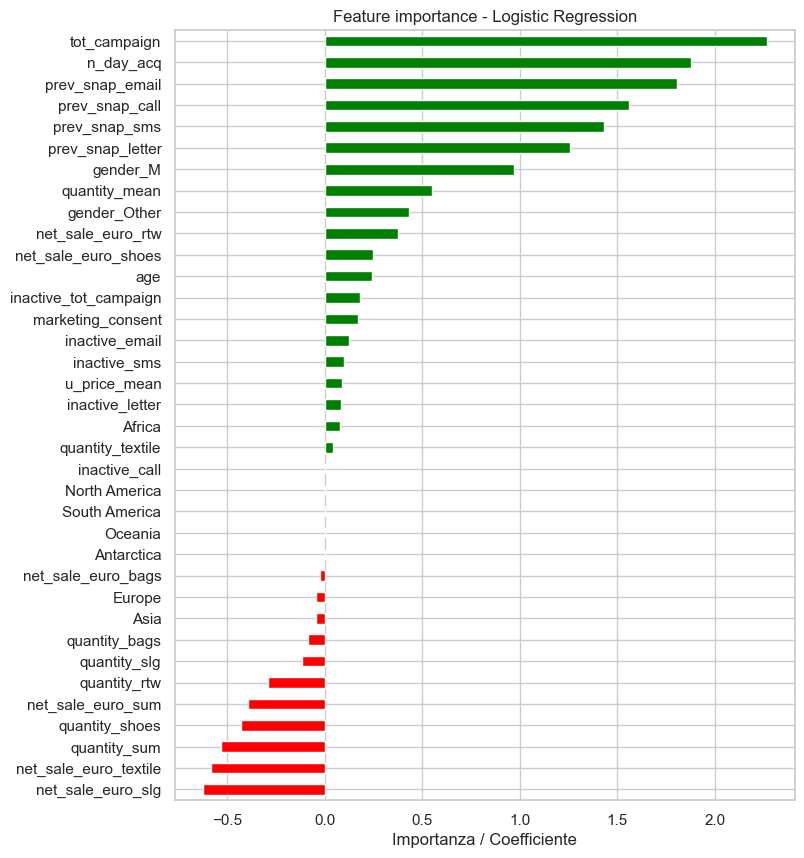

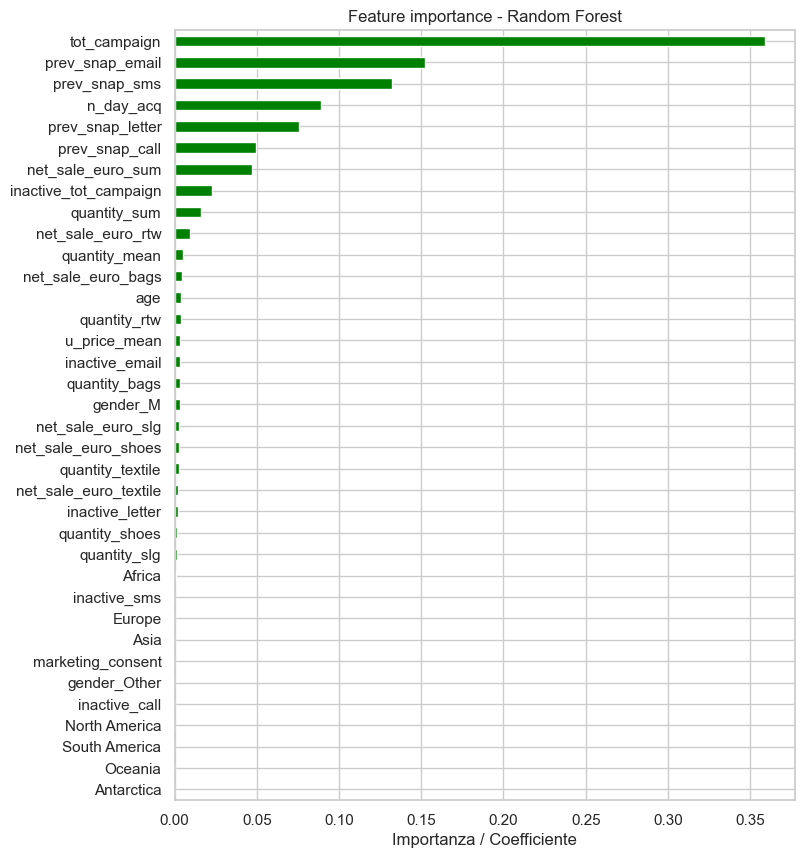

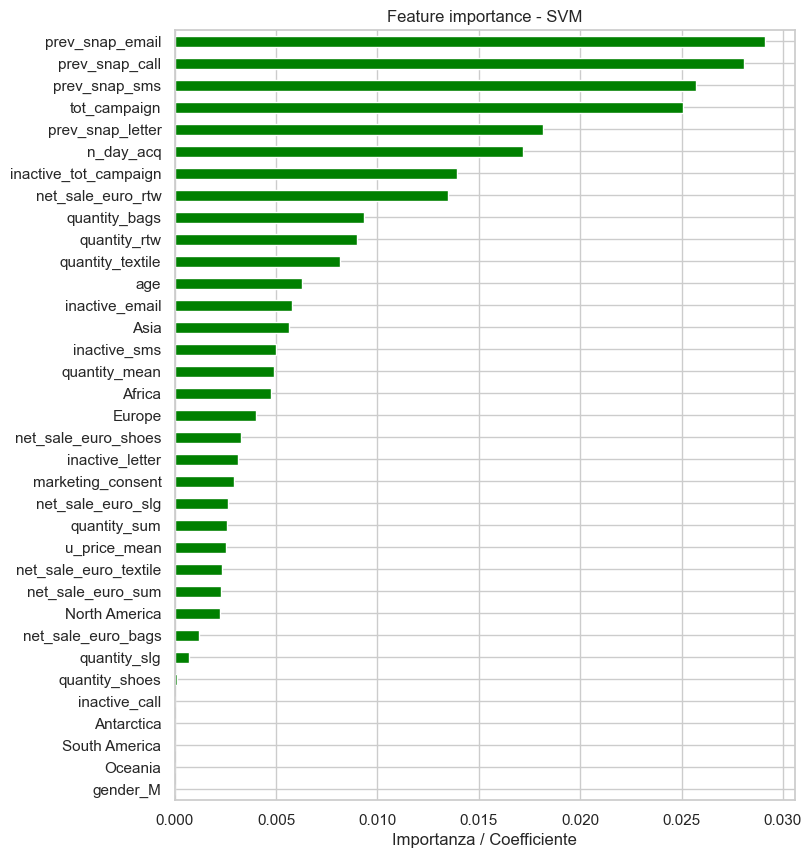

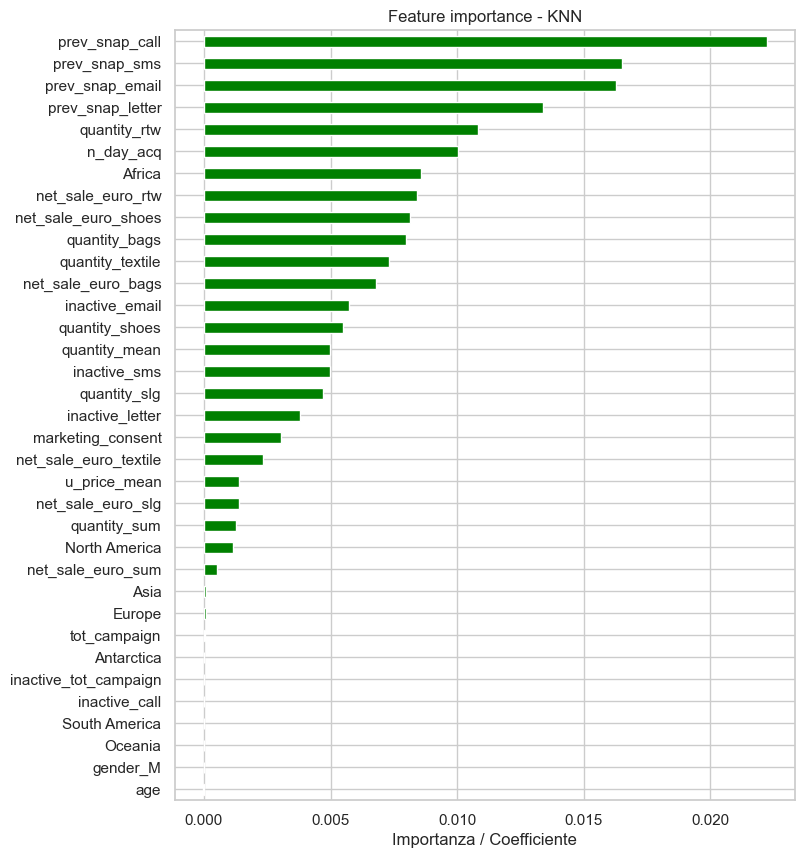


Logistic Regression
tot_campaign             2.265320
n_day_acq                1.876572
prev_snap_email          1.807520
prev_snap_call           1.561448
prev_snap_sms            1.430740
prev_snap_letter         1.259937
gender_M                 0.970681
quantity_mean            0.550524
gender_Other             0.433798
net_sale_euro_rtw        0.377590
net_sale_euro_shoes      0.246513
age                      0.243782
inactive_tot_campaign    0.179929
marketing_consent        0.170839
inactive_email           0.126674
inactive_sms             0.097048
u_price_mean             0.090586
inactive_letter          0.082326
Africa                   0.079983
quantity_textile         0.042723
Oceania                  0.000000
inactive_call            0.000000
North America            0.000000
South America            0.000000
Antarctica               0.000000
net_sale_euro_bags      -0.024901
Europe                  -0.042110
Asia                    -0.044575
quantity_bags           -0.

In [24]:
# dizionario con importanza feature
feature_importances = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    pipe.fit(X, y)

    feature_names = get_feature_names(preprocessor)
    clf = pipe.named_steps["classifier"]

    # logistic regression / linear SVM
    if hasattr(clf, "coef_"):
        importances = clf.coef_[0]
        feature_importances[name] = dict(zip(feature_names, importances))

    # random forest / tree-based
    elif hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        feature_importances[name] = dict(zip(feature_names, importances))

    # modelli senza attributo nativo (es. KNN, SVC RBF)
    else:
        r = permutation_importance(pipe, X, y, n_repeats=10, random_state=42)
        importances = r.importances_mean
        feature_importances[name] = dict(zip(feature_names, importances))

    # --- grafico ---
    fi = pd.Series(feature_importances[name]).sort_values()
    plt.figure(figsize=(8, 10))
    fi.plot(kind="barh", color=fi.apply(lambda x: "green" if x > 0 else "red"))
    plt.title(f"Feature importance - {name}")
    plt.xlabel("Importanza / Coefficiente")
    plt.show()

# mostra anche in tabella
for model_name, importances in feature_importances.items():
    print(f"\n{model_name}")
    fi = pd.Series(importances).sort_values(ascending=False)
    print(fi)